In [2]:
# Load Breast Cancer Dataset
data = load_breast_cancer()

print("Dataset Description")
print(data.DESCR)

print("\nFeature Names")
print(data.feature_names)

print("\nTarget Names")
print(data.target_names)

print("\nData Shape")
print("Samples:", data.data.shape[0])
print("Features:", data.data.shape[1])

Dataset Description
.. _breast_cancer_dataset:

Breast cancer wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is W

In [3]:
class Node:
    def __init__(self, feature_idx=None, threshold=None, left=None, right=None, value=None):
        self.feature_idx = feature_idx
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

In [4]:
class DecisionTree:
    def __init__(self, max_depth=None, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.root = None
        self.feature_importances_ = None

    def _gini(self, y):
        classes = np.unique(y)
        gini = 1.0

        for c in classes:
            p = np.sum(y == c) / len(y)
            gini -= p ** 2

        return gini

    def _best_split(self, X, y):
        best_gini = float('inf')
        best_feature = None
        best_threshold = None

        feature_importance = np.zeros(X.shape[1])

        for feature_idx in range(X.shape[1]):
            thresholds = np.unique(X[:, feature_idx])

            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold

                if (
                    np.sum(left_mask) < self.min_samples_split
                    or np.sum(~left_mask) < self.min_samples_split
                ):
                    continue

                left_gini = self._gini(y[left_mask])
                right_gini = self._gini(y[~left_mask])

                weighted_gini = (
                    left_gini * np.sum(left_mask)
                    + right_gini * np.sum(~left_mask)
                ) / len(y)

                if weighted_gini < best_gini:
                    best_gini = weighted_gini
                    best_feature = feature_idx
                    best_threshold = threshold

                feature_importance[feature_idx] += (1 - weighted_gini)

        if np.sum(feature_importance) > 0:
            self.feature_importances_ = (
                feature_importance / np.sum(feature_importance)
            )

        return best_feature, best_threshold

    def _build_tree(self, X, y, depth=0):
        if (
            depth == self.max_depth
            or len(np.unique(y)) == 1
            or len(y) < self.min_samples_split
        ):
            return Node(value=np.argmax(np.bincount(y)))

        feature_idx, threshold = self._best_split(X, y)

        if feature_idx is None:
            return Node(value=np.argmax(np.bincount(y)))

        left_mask = X[:, feature_idx] <= threshold

        left = self._build_tree(
            X[left_mask],
            y[left_mask],
            depth + 1
        )

        right = self._build_tree(
            X[~left_mask],
            y[~left_mask],
            depth + 1
        )

        return Node(feature_idx, threshold, left, right)

    def fit(self, X, y):
        self.root = self._build_tree(X, y)
        return self

    def _predict_one(self, x, node):
        while node.value is None:
            if x[node.feature_idx] <= node.threshold:
                node = node.left
            else:
                node = node.right

        return node.value

    def predict(self, X):
        return np.array(
            [self._predict_one(x, self.root) for x in X]
        )

    def plot_feature_importance(self, feature_names):
        if self.feature_importances_ is None:
            raise ValueError(
                "Fit the model first to compute feature importances"
            )

        indices = np.argsort(self.feature_importances_)[::-1]

        plt.figure(figsize=(12, 6))
        plt.title("Feature Importances")

        plt.bar(
            range(len(feature_names)),
            self.feature_importances_[indices]
        )

        plt.xticks(
            range(len(feature_names)),
            [feature_names[i] for i in indices],
            rotation=90
        )

        plt.tight_layout()
        plt.savefig("feature_importance.png", dpi=300)
        plt.show()

In [5]:
X = data.data
y = data.target

feature_names = data.feature_names
target_names = data.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1100
)

In [6]:
tree = DecisionTree(
    max_depth=4,
    min_samples_split=10
)

tree.fit(X_train, y_train)

In [7]:
y_pred = tree.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=target_names
    )
)

Accuracy: 0.9386

Classification Report:
              precision    recall  f1-score   support

   malignant       0.93      0.91      0.92        43
      benign       0.94      0.96      0.95        71

    accuracy                           0.94       114
   macro avg       0.94      0.93      0.93       114
weighted avg       0.94      0.94      0.94       114



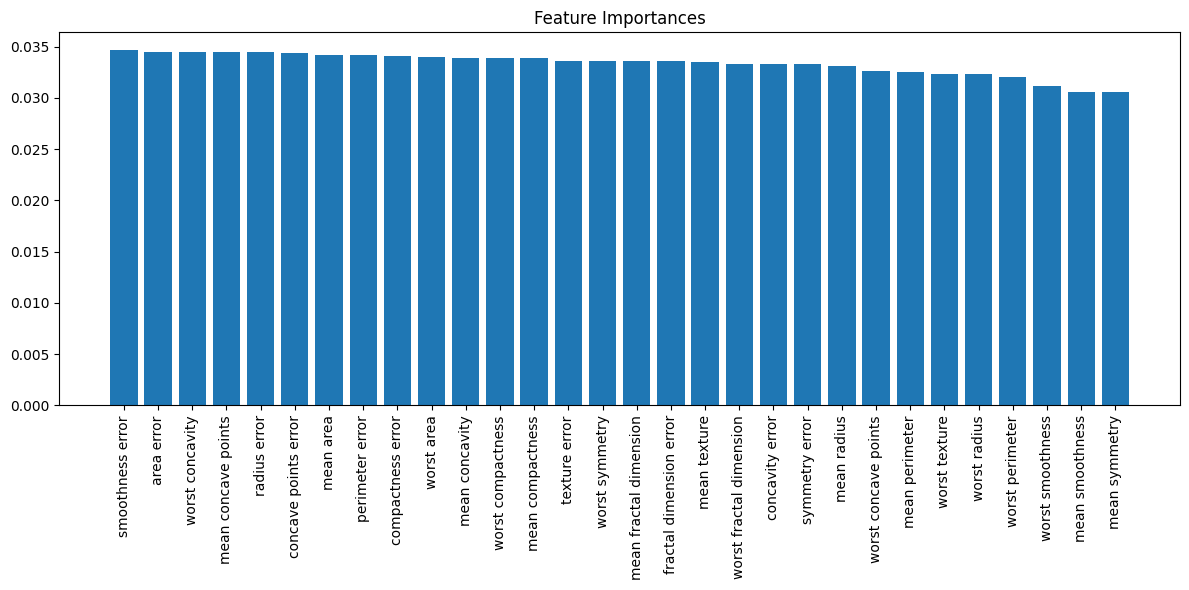

Top 10 Important Features:
1. smoothness error (0.0347)
2. area error (0.0345)
3. worst concavity (0.0344)
4. mean concave points (0.0344)
5. radius error (0.0344)
6. concave points error (0.0344)
7. mean area (0.0342)
8. perimeter error (0.0342)
9. compactness error (0.0341)
10. worst area (0.0340)


In [8]:
tree.plot_feature_importance(feature_names)

top_10_idx = np.argsort(
    tree.feature_importances_
)[-10:][::-1]

print("Top 10 Important Features:")

for i, idx in enumerate(top_10_idx, 1):
    print(
        f"{i}. {feature_names[idx]} "
        f"({tree.feature_importances_[idx]:.4f})"
    )

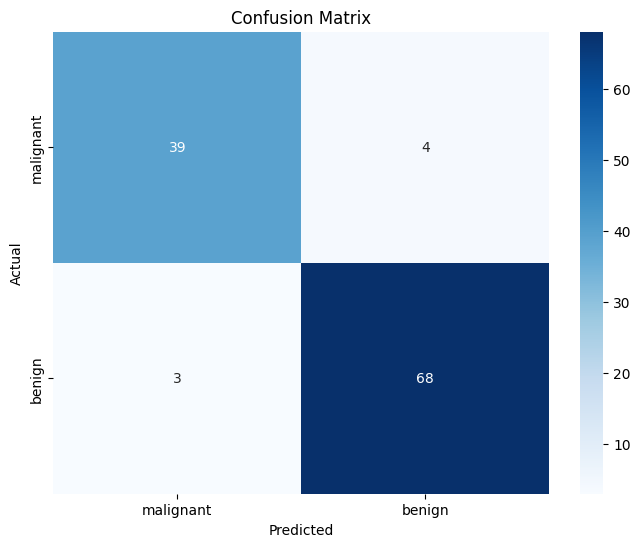

In [9]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.savefig("confusion_matrix.png", dpi=300)
plt.show()